# Classifier-Free Guidance (CFG) for Conditional Diffusion Models

> **Difficulty:** Beginner-Intermediate | **Time:** ~30 min

A diffusion model can generate diverse samples from noise -- but how do we tell it *what* to generate? "Give me class 0, not class 2." This is the problem of **conditional generation**, and classifier-free guidance (CFG) is the elegant solution used in every modern diffusion system -- Stable Diffusion, DALL-E 2, Imagen, and beyond.

In this notebook we will:
1. Understand why conditional generation matters
2. See how classifier guidance works (and its limitations)
3. Learn classifier-free guidance -- the key insight and formula
4. Train a CFG-capable model on toy 2D data
5. Sweep the guidance scale and observe the quality-diversity tradeoff
6. Explore batched CFG and negative prompts

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from mp_tutorial.diffusion import (
    linear_beta_schedule, compute_alpha_bars,
    q_sample, SimpleDenoiser, make_2d_gaussians,
    diffusion_loss, ddpm_sample_loop,
)
from mp_tutorial.diffusion_viz import draw_denoising_trajectory, draw_guidance_scale_effect
from mp_tutorial.formatting import info_box
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)

---
## 1. Why Conditional Generation?

An **unconditional** diffusion model learns to sample from the full data distribution $p(x)$. It can generate diverse outputs, but you have no control over *what* it produces.

A **conditional** model learns $p(x \mid y)$, where $y$ is a **condition** -- a class label, text prompt, sketch, or any guiding signal. This lets you say: "Generate a sample belonging to class 2" or "Generate an image matching this text description."

**Analogy:** An unconditional model is an artist told "paint something." A conditional model hears "paint a sunset over the ocean."

Let's build intuition with a toy 2D dataset: four Gaussian clusters (classes 0--3) arranged in a circle.

Dataset: 2000 points, 4 classes
data shape:   torch.Size([2000, 2])
labels shape: torch.Size([2000])
Label values:  [0, 1, 2, 3]


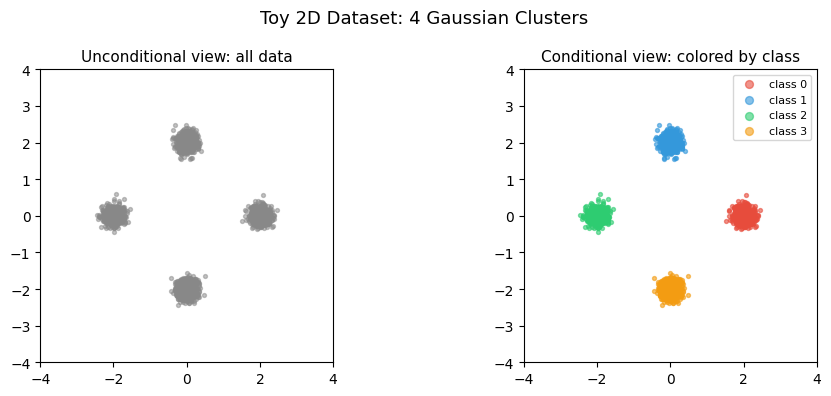


An unconditional model generates from the whole distribution.
A conditional model generates from ONE cluster at a time -- that's the goal.


In [2]:
# Create toy 2D data: 4 Gaussian clusters with class labels
data, labels = make_2d_gaussians(n_points=2000, n_modes=4, std=0.15, radius=2.0, seed=42)

print(f"Dataset: {len(data)} points, 4 classes")
print(f"data shape:   {data.shape}")
print(f"labels shape: {labels.shape}")
print(f"Label values:  {sorted(labels.unique().tolist())}")

# Visualize: unconditional vs conditional view
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

# Left: all data lumped together (unconditional)
axes[0].scatter(data[:, 0].numpy(), data[:, 1].numpy(), s=8, alpha=0.5, c="#888")
axes[0].set_title("Unconditional view: all data", fontsize=11)
axes[0].set_xlim(-4, 4); axes[0].set_ylim(-4, 4)
axes[0].set_aspect("equal")

# Right: colored by class (conditional)
for c in range(4):
    mask = labels == c
    axes[1].scatter(data[mask, 0].numpy(), data[mask, 1].numpy(),
                    s=8, alpha=0.6, c=colors[c], label=f"class {c}")
axes[1].legend(fontsize=8, markerscale=2)
axes[1].set_title("Conditional view: colored by class", fontsize=11)
axes[1].set_xlim(-4, 4); axes[1].set_ylim(-4, 4)
axes[1].set_aspect("equal")

fig.suptitle("Toy 2D Dataset: 4 Gaussian Clusters", fontsize=13)
fig.tight_layout()
plt.show()

print("\nAn unconditional model generates from the whole distribution.")
print("A conditional model generates from ONE cluster at a time -- that's the goal.")

---
## 2. Classifier Guidance

The first approach to steering diffusion was **classifier guidance** (Dhariwal & Nichol, 2021).

### The idea

1. Train a diffusion model that generates **unconditionally** -- it learns $\epsilon_\theta(x_t, t)$.
2. Separately train a **classifier** $p_\phi(y \mid x_t)$ that works on *noisy* images at every timestep $t$.
3. At sampling time, use the classifier's gradient to push samples toward the desired class.

### The formula

By Bayes' rule:
$$\nabla_{x_t} \log p(x_t \mid y) = \nabla_{x_t} \log p(x_t) + \nabla_{x_t} \log p(y \mid x_t)$$

In noise-prediction form with a guidance scale $s$:

$$\tilde\epsilon = \epsilon_\theta(x_t, t) - s \cdot \nabla_{x_t} \log p_\phi(y|x_t)$$

The classifier gradient acts like a compass -- pointing noisy samples toward the target class at each step.

### Problems with classifier guidance

- You need to train a **separate classifier** on noisy data at every noise level
- The classifier must be **differentiable** (you need gradients w.r.t. $x_t$)
- Extra training cost, extra model to maintain
- The classifier may have its own biases that distort generation

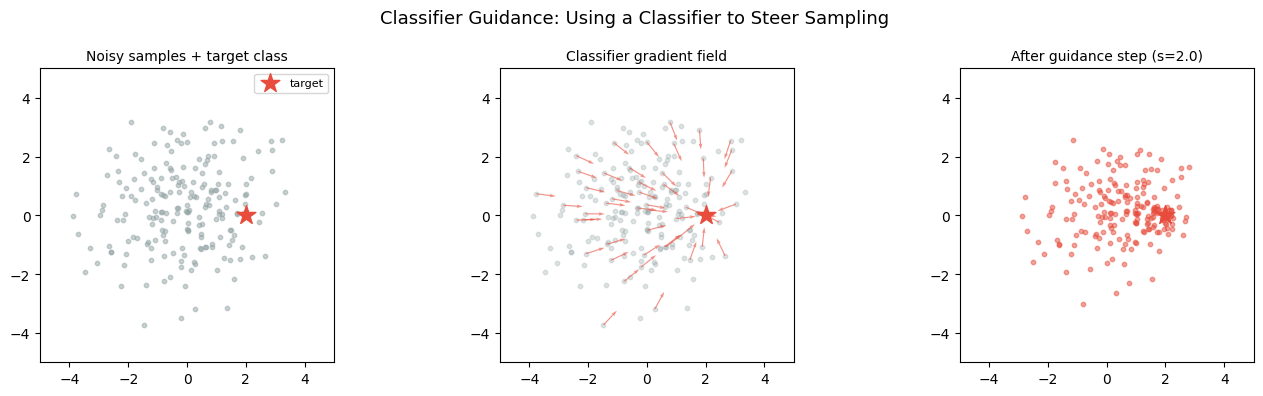

In [3]:
# Visualize the *concept* of classifier guidance on toy data
# (We won't train a full classifier -- just show the gradient direction)

torch.manual_seed(42)
n_pts = 200
x_noisy = torch.randn(n_pts, 2) * 1.5  # scattered noisy samples

# Class 0 center is roughly at (2, 0) in our dataset
target_center = torch.tensor([2.0, 0.0])

# The classifier gradient points toward the target class
grad_log_p = target_center.unsqueeze(0) - x_noisy
grad_log_p = grad_log_p / (grad_log_p.norm(dim=1, keepdim=True) + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: noisy samples
axes[0].scatter(x_noisy[:, 0].numpy(), x_noisy[:, 1].numpy(), s=10, alpha=0.5, c="#95a5a6")
axes[0].scatter(*target_center.numpy(), s=200, c="#e74c3c", marker="*", zorder=5, label="target")
axes[0].legend(fontsize=8)
axes[0].set_title("Noisy samples + target class", fontsize=10)
axes[0].set_xlim(-5, 5); axes[0].set_ylim(-5, 5); axes[0].set_aspect("equal")

# Panel 2: gradient arrows
step = 4
axes[1].scatter(x_noisy[:, 0].numpy(), x_noisy[:, 1].numpy(), s=10, alpha=0.3, c="#95a5a6")
axes[1].quiver(x_noisy[::step, 0].numpy(), x_noisy[::step, 1].numpy(),
               grad_log_p[::step, 0].numpy(), grad_log_p[::step, 1].numpy(),
               scale=15, alpha=0.6, color="#e74c3c", width=0.004)
axes[1].scatter(*target_center.numpy(), s=200, c="#e74c3c", marker="*", zorder=5)
axes[1].set_title("Classifier gradient field", fontsize=10)
axes[1].set_xlim(-5, 5); axes[1].set_ylim(-5, 5); axes[1].set_aspect("equal")

# Panel 3: after one guidance step
s_guide = 2.0
x_guided = x_noisy + s_guide * grad_log_p * 0.5
axes[2].scatter(x_guided[:, 0].numpy(), x_guided[:, 1].numpy(), s=10, alpha=0.5, c="#e74c3c")
axes[2].scatter(*target_center.numpy(), s=200, c="#e74c3c", marker="*", zorder=5)
axes[2].set_title(f"After guidance step (s={s_guide})", fontsize=10)
axes[2].set_xlim(-5, 5); axes[2].set_ylim(-5, 5); axes[2].set_aspect("equal")

fig.suptitle("Classifier Guidance: Using a Classifier to Steer Sampling", fontsize=13)
fig.tight_layout()
plt.show()

In [4]:
info_box(
    "Classifier guidance was the original approach (Dhariwal & Nichol, 2021) "
    "but it requires training an extra classifier model that works on noisy data. "
    "This adds complexity and cost. Classifier-free guidance eliminates this extra model entirely.",
    title="Why move beyond classifier guidance?"
)

---
## 3. Classifier-Free Guidance (CFG)

### The key insight

What if we don't need a separate classifier at all? What if the diffusion model itself could handle both conditional and unconditional generation?

**Classifier-free guidance** (Ho & Salimans, 2022) does exactly this.

### Training

Train a single noise-prediction network $\epsilon_\theta(x_t, t, c)$ that accepts an optional condition $c$. During training, randomly **drop the condition** with probability $p_{\text{uncond}}$ (typically 10--20%), replacing it with a null token $\varnothing$:

$$c_{\text{train}} = \begin{cases} c & \text{with probability } 1 - p_{\text{uncond}} \\ \varnothing & \text{with probability } p_{\text{uncond}} \end{cases}$$

This way, the **same model** learns both:
- $\epsilon_\theta(x_t, t, c)$ -- conditional prediction ("denoise toward class $c$")
- $\epsilon_\theta(x_t, t, \varnothing)$ -- unconditional prediction ("denoise toward anything")

### Inference

At inference, we combine both predictions using a **guidance scale** $w$:

$$\boxed{\tilde{\epsilon} = \epsilon_\theta(x_t, t, \varnothing) + w \cdot \big(\epsilon_\theta(x_t, t, y) - \epsilon_\theta(x_t, t, \varnothing)\big)}$$

| $w$ value | Meaning |
|---|---|
| $w = 0$ | Purely unconditional (ignores the condition entirely) |
| $w = 1$ | Standard conditional generation (no extra guidance) |
| $w > 1$ | **Amplified** conditioning -- overshoots toward the condition |

The term $(\epsilon_{\text{cond}} - \epsilon_{\text{uncond}})$ is the **condition direction** -- the model's estimate of how the condition changes the noise prediction. Multiplying by $w > 1$ amplifies this direction.

In [5]:
info_box(
    "<b>Label dropout</b> is the training trick that makes CFG work. "
    "By randomly replacing class labels with a null token during training "
    "(e.g., 10% of the time), the model learns to predict noise both "
    "with and without the condition. No extra model needed!",
    title="Key idea: random label dropout"
)

In [6]:
# Train a classifier-free guidance model on the 2D Gaussian data
torch.manual_seed(0)

T = 100
betas = linear_beta_schedule(T)
alpha_bars = compute_alpha_bars(betas)

# SimpleDenoiser supports class conditioning via n_classes parameter.
# It uses n_classes+1 embeddings (the extra one is the null/unconditional token).
model = SimpleDenoiser(data_dim=2, hidden=128, n_classes=4, time_dim=32)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Null class index: {model.n_classes} (used when label is dropped)")
print(f"Training with p_uncond=0.1 (10% label dropout)...\n")

losses = []
for epoch in range(300):
    loss = diffusion_loss(model, data, alpha_bars, labels=labels, p_uncond=0.1)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 100 == 0:
        print(f"  Epoch {epoch+1:3d}/300  loss = {loss.item():.4f}")

print("\nTraining complete!")

Model parameters: 42,018
Null class index: 4 (used when label is dropped)
Training with p_uncond=0.1 (10% label dropout)...



  Epoch 100/300  loss = 0.4348


  Epoch 200/300  loss = 0.3056


  Epoch 300/300  loss = 0.2964

Training complete!


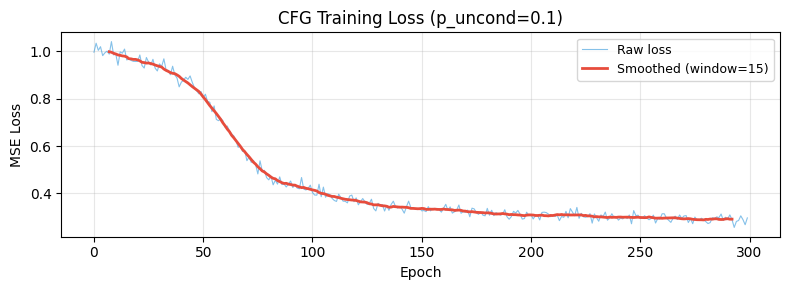

Final loss: 0.2964
The model learned both conditional and unconditional denoising in one network.


In [7]:
# Plot training loss curve
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses, linewidth=0.8, alpha=0.6, color="#3498db", label="Raw loss")

# Smoothed curve
window = 15
smoothed = np.convolve(losses, np.ones(window)/window, mode="valid")
ax.plot(range(window//2, window//2 + len(smoothed)), smoothed,
        linewidth=2, color="#e74c3c", label=f"Smoothed (window={window})")

ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.set_title("CFG Training Loss (p_uncond=0.1)", fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Final loss: {losses[-1]:.4f}")
print(f"The model learned both conditional and unconditional denoising in one network.")

In [8]:
# Demonstrate CFG math: compare conditional vs unconditional predictions
model.eval()
torch.manual_seed(7)

n_demo = 8
x_0_demo = data[:n_demo]
c_demo = labels[:n_demo]
t_demo = torch.full((n_demo,), 50, dtype=torch.long)
x_t, _ = q_sample(x_0_demo, t_demo, alpha_bars)

with torch.no_grad():
    eps_cond = model(x_t, t_demo, c_demo)          # conditional
    eps_uncond = model(x_t, t_demo, None)           # unconditional (null class)

print("CFG formula: eps_guided = eps_uncond + w * (eps_cond - eps_uncond)\n")
print(f"{'w':>5}  {'dist from eps_cond':>20}  {'dist from eps_uncond':>22}")
print("-" * 52)
for w in [0.0, 1.0, 3.0, 7.0]:
    eps_guided = eps_uncond + w * (eps_cond - eps_uncond)
    d_cond = (eps_guided - eps_cond).norm(dim=1).mean().item()
    d_uncond = (eps_guided - eps_uncond).norm(dim=1).mean().item()
    print(f"{w:5.1f}  {d_cond:20.4f}  {d_uncond:22.4f}")

print("\nAt w=1, eps_guided = eps_cond exactly (standard conditional generation).")
print("At w>1, we overshoot past eps_cond -- amplifying the condition's effect.")

CFG formula: eps_guided = eps_uncond + w * (eps_cond - eps_uncond)

    w    dist from eps_cond    dist from eps_uncond
----------------------------------------------------
  0.0                0.9688                  0.0000
  1.0                0.0000                  0.9688
  3.0                1.9377                  2.9065
  7.0                5.8130                  6.7818

At w=1, eps_guided = eps_cond exactly (standard conditional generation).
At w>1, we overshoot past eps_cond -- amplifying the condition's effect.


---
## 4. Effect of Guidance Scale

The guidance scale $w$ controls a fundamental tradeoff:

| $w$ | Behavior | Quality | Diversity |
|-----|----------|---------|-----------|
| 0 | Purely unconditional | Low | High |
| 1 | Standard conditional | Medium | Medium |
| 3--7 | Amplified (sweet spot) | High | Medium-Low |
| >15 | Over-conditioned | Degrades | Very Low |

Let's see this empirically by sweeping $w$ and generating samples for class 0.

In [9]:
# Generate samples at different guidance scales for class 0
model.eval()
target_class = 0
n_samples = 500
w_values = [0.0, 1.0, 3.0, 7.0, 15.0]
samples_by_w = {}

for w in w_values:
    torch.manual_seed(42)  # same initial noise for fair comparison
    class_labels = torch.full((n_samples,), target_class, dtype=torch.long)

    if w == 0.0:
        # w=0 means purely unconditional
        samples = ddpm_sample_loop(
            model, betas, alpha_bars, shape=(n_samples, 2),
            labels=None, guidance_scale=1.0
        )
    else:
        samples = ddpm_sample_loop(
            model, betas, alpha_bars, shape=(n_samples, 2),
            labels=class_labels, guidance_scale=w
        )

    samples_by_w[w] = samples.detach()
    print(f"w={w:5.1f}  generated {n_samples} samples")

print("\nDone! Now let's visualize.")

w=  0.0  generated 500 samples


w=  1.0  generated 500 samples
w=  3.0  generated 500 samples


w=  7.0  generated 500 samples
w= 15.0  generated 500 samples

Done! Now let's visualize.


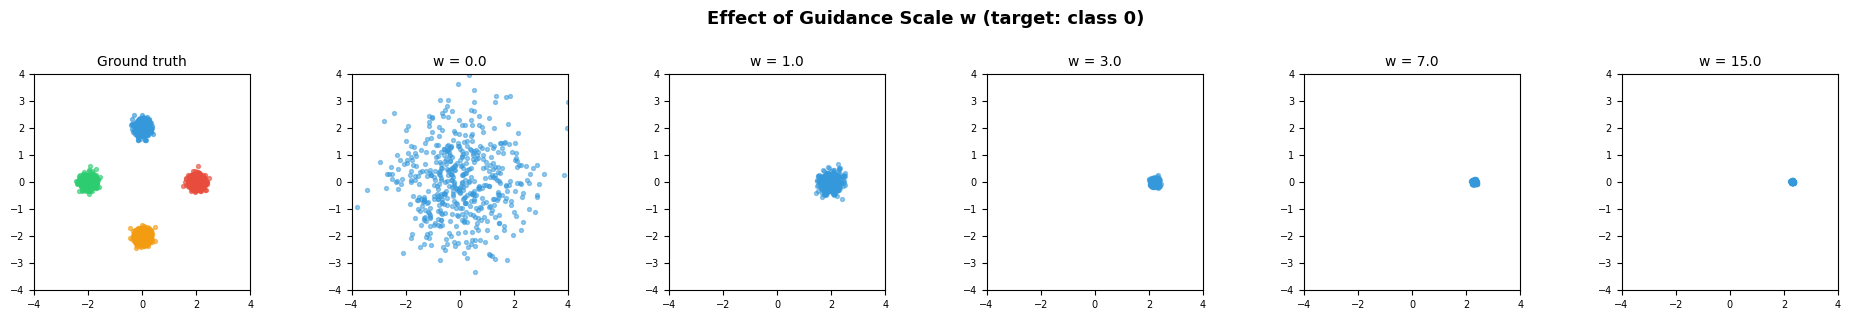

w=0.0:  Unconditional -- samples spread across ALL clusters.
w=1.0:  Standard conditional -- near class 0, but some spread.
w=3.0:  Amplified -- tighter clustering around class 0.
w=7.0:  Strongly amplified -- very tight, may lose diversity.
w=15.0: Over-guided -- risk of mode collapse or artifacts.


In [10]:
# Visualize guidance scale sweep using the helper function
fig, axes = draw_guidance_scale_effect(
    samples_by_w,
    true_data=data,
    true_labels=labels,
    n_classes=4,
    title=f"Effect of Guidance Scale w (target: class {target_class})"
)
plt.show()

print("w=0.0:  Unconditional -- samples spread across ALL clusters.")
print("w=1.0:  Standard conditional -- near class 0, but some spread.")
print("w=3.0:  Amplified -- tighter clustering around class 0.")
print("w=7.0:  Strongly amplified -- very tight, may lose diversity.")
print("w=15.0: Over-guided -- risk of mode collapse or artifacts.")

In [11]:
# Quantify the quality-diversity tradeoff
target_center = torch.tensor([2.0, 0.0])  # approximate center of class 0

print(f"{'w':>5} | {'Mean dist to center':>20} | {'Spread (std)':>15} | {'Interpretation':>25}")
print("-" * 75)

for w in w_values:
    s = samples_by_w[w]
    dist = (s - target_center).norm(dim=1)
    mean_dist = dist.mean().item()
    std_val = s.std(dim=0).norm().item()

    if w == 0:
        interp = "Ignores condition"
    elif w == 1:
        interp = "Normal conditioning"
    elif w <= 7:
        interp = "Amplified (sweet spot)"
    else:
        interp = "Over-conditioned"

    print(f"{w:5.1f} | {mean_dist:20.3f} | {std_val:15.3f} | {interp:>25}")

print("\nHigher w => lower spread (less diversity) but better alignment (higher quality).")
print("Push w too high and samples collapse to a single point.")

    w |  Mean dist to center |    Spread (std) |            Interpretation
---------------------------------------------------------------------------
  0.0 |                2.456 |           1.801 |         Ignores condition
  1.0 |                0.254 |           0.283 |       Normal conditioning
  3.0 |                0.232 |           0.109 |    Amplified (sweet spot)
  7.0 |                0.291 |           0.055 |    Amplified (sweet spot)
 15.0 |                0.310 |           0.029 |          Over-conditioned

Higher w => lower spread (less diversity) but better alignment (higher quality).
Push w too high and samples collapse to a single point.


In [12]:
info_box(
    "The optimal guidance scale depends on the task. "
    "Text-to-image models typically use <b>w = 7 -- 8.5</b> (Stable Diffusion default is 7.5). "
    "Too low gives blurry, unfocused results. "
    "Too high gives oversaturated or artifact-laden images. "
    "The sweet spot balances quality and diversity.",
    title="Choosing the guidance scale in practice"
)

---
## 5. Batched CFG: The 2x Cost

The CFG formula requires **two forward passes** per sampling step:
1. $\epsilon_\theta(x_t, t, c)$ -- conditional prediction
2. $\epsilon_\theta(x_t, t, \varnothing)$ -- unconditional prediction

This **doubles inference cost** compared to a model without guidance.

In production, both forward passes are **batched into a single call** by concatenating the inputs:

```python
# Batch both passes together
x_double = torch.cat([x_t, x_t])           # [2B, D]
t_double = torch.cat([t, t])               # [2B]
c_double = torch.cat([c, null_tokens])     # [2B]
eps_both = model(x_double, t_double, c_double)  # single call
eps_cond, eps_uncond = eps_both.chunk(2)
```

In [13]:
# Demonstrate batched CFG -- identical results in one forward pass
model.eval()
torch.manual_seed(42)

B = 4
x_t = torch.randn(B, 2)
t_batch = torch.full((B,), 50, dtype=torch.long)
c_batch = torch.zeros(B, dtype=torch.long)            # class 0
null_batch = torch.full((B,), model.n_classes, dtype=torch.long)  # null class

# Method 1: Two separate forward passes (naive)
fwd_count_naive = 0
with torch.no_grad():
    eps_cond_v1 = model(x_t, t_batch, c_batch);     fwd_count_naive += 1
    eps_uncond_v1 = model(x_t, t_batch, null_batch); fwd_count_naive += 1

# Method 2: Single batched forward pass (production)
fwd_count_batched = 0
with torch.no_grad():
    x_double = torch.cat([x_t, x_t], dim=0)            # [2B, 2]
    t_double = torch.cat([t_batch, t_batch], dim=0)     # [2B]
    c_double = torch.cat([c_batch, null_batch], dim=0)  # [2B]
    eps_both = model(x_double, t_double, c_double);  fwd_count_batched += 1
    eps_cond_v2, eps_uncond_v2 = eps_both.chunk(2, dim=0)

# Verify identical results
print("Batched CFG produces identical results:")
print(f"  eps_cond match:   {torch.allclose(eps_cond_v1, eps_cond_v2)}")
print(f"  eps_uncond match: {torch.allclose(eps_uncond_v1, eps_uncond_v2)}")
print(f"\nForward pass count:")
print(f"  Naive (separate):   {fwd_count_naive} calls")
print(f"  Batched (production): {fwd_count_batched} call (2x batch size)")

# Apply CFG
w = 7.5
eps_guided = eps_uncond_v2 + w * (eps_cond_v2 - eps_uncond_v2)
print(f"\nGuided prediction (w={w}):  shape = {eps_guided.shape}")

Batched CFG produces identical results:
  eps_cond match:   True
  eps_uncond match: True

Forward pass count:
  Naive (separate):   2 calls
  Batched (production): 1 call (2x batch size)

Guided prediction (w=7.5):  shape = torch.Size([4, 2])


In [14]:
info_box(
    "In production, both forward passes are batched together to maximize GPU utilization. "
    "This is why many diffusion model inference engines use <b>batch_size=2</b> internally "
    "even when generating a single image. The 2x compute cost is universally accepted "
    "because the quality improvement from CFG is transformative.",
    title="Batched CFG in production"
)

print("See [Continuous Batching](../../en/inference/02-continuous-batching.ipynb)")
print("for how batching optimizes GPU utilization in inference servers.")

See [Continuous Batching](../../en/inference/02-continuous-batching.ipynb)
for how batching optimizes GPU utilization in inference servers.


---
## 6. Negative Prompts

A popular extension of CFG: instead of using the null class $\varnothing$ for the unconditional pass, use a **negative condition** $y_{\text{neg}}$ -- something you want to **avoid**.

The formula becomes:

$$\tilde{\epsilon} = \epsilon_\theta(x_t, t, y_{\text{neg}}) + w \cdot \big(\epsilon_\theta(x_t, t, y) - \epsilon_\theta(x_t, t, y_{\text{neg}})\big)$$

The condition direction now points **away from the negative class** and **toward the positive class**. This is a free feature of the CFG framework -- no retraining needed!

Let's demonstrate: generate class 0 samples, with class 2 as the negative.

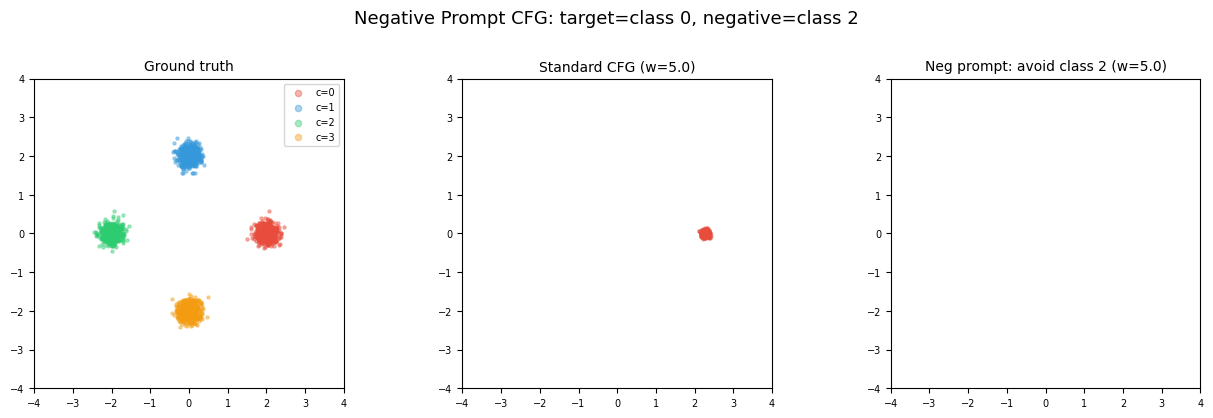

Standard CFG uses the null class as baseline.
Negative prompt CFG uses class 2 as baseline.
The negative prompt pushes samples AWAY from class 2.


In [15]:
# Negative prompt demo: generate class 0, avoid class 2
model.eval()
n_samples = 500
target_class = 0
negative_class = 2
w = 5.0

class_labels = torch.full((n_samples,), target_class, dtype=torch.long)
neg_labels = torch.full((n_samples,), negative_class, dtype=torch.long)

# Standard CFG (null class as baseline)
torch.manual_seed(42)
samples_standard = ddpm_sample_loop(
    model, betas, alpha_bars, shape=(n_samples, 2),
    labels=class_labels, guidance_scale=w
).detach()

# Negative prompt CFG: use class 2 as baseline instead of null
torch.manual_seed(42)
x = torch.randn(n_samples, 2)
for i in reversed(range(T)):
    t_b = torch.full((n_samples,), i, dtype=torch.long)
    with torch.no_grad():
        eps_cond = model(x, t_b, class_labels)
        eps_neg = model(x, t_b, neg_labels)  # negative class instead of null
    eps = eps_neg + w * (eps_cond - eps_neg)

    abar = alpha_bars[i]
    abar_prev = alpha_bars[i - 1] if i > 0 else torch.tensor(1.0)
    alpha_i = 1.0 - betas[i]
    x_0_pred = (x - (1 - abar).sqrt() * eps) / abar.sqrt()
    coeff1 = betas[i] * abar_prev.sqrt() / (1 - abar)
    coeff2 = (1 - abar_prev) * alpha_i.sqrt() / (1 - abar)
    mean = coeff1 * x_0_pred + coeff2 * x
    if i > 0:
        x = mean + betas[i].sqrt() * torch.randn_like(x)
    else:
        x = mean
samples_neg_prompt = x.detach()

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Ground truth
for c in range(4):
    mask = labels == c
    axes[0].scatter(data[mask, 0].numpy(), data[mask, 1].numpy(),
                    s=5, alpha=0.4, c=colors[c], label=f"c={c}")
axes[0].legend(fontsize=7, markerscale=2)
axes[0].set_title("Ground truth", fontsize=10)

# Standard CFG
axes[1].scatter(samples_standard[:, 0].numpy(), samples_standard[:, 1].numpy(),
                s=5, alpha=0.4, c="#e74c3c")
axes[1].set_title(f"Standard CFG (w={w})", fontsize=10)

# Negative prompt CFG
axes[2].scatter(samples_neg_prompt[:, 0].numpy(), samples_neg_prompt[:, 1].numpy(),
                s=5, alpha=0.4, c="#e74c3c")
axes[2].set_title(f"Neg prompt: avoid class {negative_class} (w={w})", fontsize=10)

for ax in axes:
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4); ax.set_aspect("equal")
    ax.tick_params(labelsize=7)

fig.suptitle(f"Negative Prompt CFG: target=class {target_class}, negative=class {negative_class}",
             fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

print(f"Standard CFG uses the null class as baseline.")
print(f"Negative prompt CFG uses class {negative_class} as baseline.")
print(f"The negative prompt pushes samples AWAY from class {negative_class}.")

In [16]:
info_box(
    "Negative prompts are widely used in Stable Diffusion and other text-to-image models. "
    "Common negative prompts include 'blurry, low quality, deformed, bad anatomy' "
    "to steer generation away from common failure modes. "
    "This works because the CFG formula naturally supports any condition as the baseline -- "
    "it doesn't have to be the null token.",
    title="Negative prompts in Stable Diffusion"
)

---
## 7. Summary + Further Reading

### Key Takeaways

1. **Classifier guidance** uses a separate classifier to steer diffusion, but requires an extra model trained on noisy data.

2. **Classifier-free guidance (CFG)** eliminates the extra model: train one denoiser with random label dropout, then combine conditional and unconditional predictions at inference.

3. **The CFG formula:** $\tilde{\epsilon} = \epsilon_{\text{uncond}} + w \cdot (\epsilon_{\text{cond}} - \epsilon_{\text{uncond}})$

4. **Guidance scale $w$** controls the quality-diversity tradeoff. $w=1$ is normal; $w=7$--$8.5$ is typical for production.

5. **Negative prompts** are a free feature of CFG -- replace the null condition with an undesirable condition.

6. **Cost:** CFG doubles compute per step (2 forward passes), but the quality improvement makes it universally adopted.

### Papers

- Ho & Salimans, ["Classifier-Free Diffusion Guidance"](https://arxiv.org/abs/2207.12598), 2022
- Dhariwal & Nichol, ["Diffusion Models Beat GANs on Image Synthesis"](https://arxiv.org/abs/2105.05233), 2021 (classifier guidance)
- Saharia et al., ["Imagen"](https://arxiv.org/abs/2205.11487), 2022 (dynamic thresholding for high $w$)

### Next

[03-latent-diffusion.ipynb](03-latent-diffusion.ipynb) -- Moving diffusion from pixel space to latent space, enabling high-resolution generation.